In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#provided MHW value for your site in [m NAVD88]
MHW_ELEVATION_NAVD88 = 0.26 
#load the water level csv file for year 2024 [m NAVD88]
water_level_NAVD = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/Daily_WL_NAVD.csv'
#loading CASCADE simulations
data = np.load (
    '/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/OCR_I_Natural_S0_Accretional_Sink.npz', allow_pickle=True)
data

NpzFile '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/OCR_I_Natural_S0_Accretional_Sink.npz' with keys: cascade

In [254]:
#define the CASCADE object
cascade_object = data['cascade'][0]

In [255]:
cascade_object.roadways[0]._road_relocated_TS

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0.])

In [256]:
# cheking RSLR and comapre them with provided values for I scenario: 0.21m, 0.55m, 0.98m, 1.47m
# Get the RSLR time series from the first Barrier3D model
rslr_time_series = cascade_object.barrier3d[0].RSLR

# Calculate the cumulative sum to get total RSLR at each year
total_rslr = np.cumsum(rslr_time_series)

# Define the years you want to check
years_to_check = [0, 24, 49, 74, 99]  

print("Total Sea Level Rise (dam) from Simulation: ")
for year in years_to_check:
    index = year
    if index < len(total_rslr):
        print(f"Year {year}: {total_rslr[index]:.3f} dam")



Total Sea Level Rise (dam) from Simulation: 
Year 0: 0.001 dam
Year 24: 0.021 dam
Year 49: 0.055 dam
Year 74: 0.098 dam
Year 99: 0.147 dam


In [257]:
#investigating road relocation
results_list = []
target_years = [0, 24, 49, 74, 99] 

if not cascade_object.roadways:
    print("The 'roadways' attribute is empty. Cannot retrieve data.")
else:
    for year in target_years:
        for i, road_segment in enumerate(cascade_object.roadways):
            road_relocate_time_series = road_segment._road_relocated_TS
            
            if year < len(road_relocate_time_series):
                relocated = road_relocate_time_series[year]
                
                result_row = {
                    'Year': year,
                    'Domain': i,
                    'Relocated': relocated
                }
                results_list.append(result_row)
                
            else:
                print(f"Data for Year {year}, Domain {i} is not available.")

#convert the list to a DataFrame and save it
if results_list:
    # Convert the list of dictionaries into a pandas DataFrame
    road_df = pd.DataFrame(results_list)
    output_filename = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/OCR_I_Natural_S0_Accretional_Sink_RoadRelocation.csv'

    road_df.to_csv(output_filename, index=False)
    print(road_df.head()) 


   Year  Domain  Relocated
0     0       0        0.0
1     0       1        0.0
2     0       2        0.0
3     0       3        0.0
4     0       4        0.0


In [258]:
#exporting road elevations (m MHW) for aech domain categorized by the years
results_list = []
target_years = [0, 24, 49, 74, 99] 

if not cascade_object.roadways:
    print("The 'roadways' attribute is empty. Cannot retrieve data.")
else:
    for year in target_years:
        for i, road_segment in enumerate(cascade_object.roadways):
            elevation_time_series = road_segment._road_ele_TS
            
            if year < len(elevation_time_series):
                elevation = elevation_time_series[year]
                
                result_row = {
                    'Year': year,
                    'Domain': i,
                    'Road_Elevation (m MHW)': elevation
                }
                results_list.append(result_row)
                
            else:
                print(f"Data for Year {year}, Domain {i} is not available.")

#convert the list to a DataFrame and save it
if results_list:
    # Convert the list of dictionaries into a pandas DataFrame
    road_df = pd.DataFrame(results_list)
    output_filename = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/OCR_I_Natural_S0_Accretional_Sink_RoadElevation.csv'

    road_df.to_csv(output_filename, index=False)
    print(road_df.head()) 


   Year  Domain  Road_Elevation (m MHW)
0     0       0                    1.45
1     0       1                    1.45
2     0       2                    1.45
3     0       3                    1.45
4     0       4                    1.45


In [259]:
#load water level
water_NAVD_df = pd.read_csv(water_level_NAVD) # (m NAVD88)
daily_tidal_levels_NAVD= water_NAVD_df['v'].values # (m NAVD88)
#converting daily water level (m NAVD88) to (m MHW)
daily_tidal_MHW = daily_tidal_levels_NAVD - MHW_ELEVATION_NAVD88 # (m MHW)

In [260]:
#export flood days to csv
analysis_output_filepath = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/OCR_I_Natural_S0_Accretional_Sink_flood_days.csv'
print(f"\n Loading data and running analysis:")
part1_success = False
results_df = None
print("Successfully loaded all input files (skipped header in water level file).")

# Perform the comparison
final_results = []
for index, road_row in road_df.iterrows():
    year = int(road_row['Year'])
    domain = int(road_row['Domain'])
    road_elevation = road_row['Road_Elevation (m MHW)']
    flooded_days = np.sum(road_elevation < daily_tidal_MHW)
    
    result_row = {
        'Year': year,
        'Domain': domain,
        'Road_Elevation': road_elevation,
        'Flooded_Days': flooded_days,
    }
    final_results.append(result_row)

# Save the analysis results to a CSV file
results_df = pd.DataFrame(final_results)
results_df.to_csv(analysis_output_filepath, index=False)
print(f"Analysis complete. Results saved to '{analysis_output_filepath}'")


 Loading data and running analysis:
Successfully loaded all input files (skipped header in water level file).
Analysis complete. Results saved to '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/OCR_I_Natural_S0_Accretional_Sink_flood_days.csv'


In [261]:
#export flood depth to csv
analysis_output_filepath = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/OCR_I_Natural_S0_Accretional_Sink_flood_depth.csv'
print(f"\n Loading data and running analysis:")
part1_success = False
results_df = None
print("Successfully loaded all input files (skipped header in water level file).")

# Perform the comparison
final_results = []
for index, road_row in road_df.iterrows():
    year = int(road_row['Year'])
    domain = int(road_row['Domain'])
    road_elevation = road_row['Road_Elevation (m MHW)']
    
    # flood days and depth analysis
    # Identify which days are flooded
    is_flooded = road_elevation < daily_tidal_MHW
    flooded_days = np.sum(is_flooded)
    
    # Calculate flood depth only on the days it flooded
    max_flood_depth = 0
    avg_flood_depth = 0
    
    if flooded_days > 0:
        # Calculate the depth for all flooded days
        flood_depths = daily_tidal_MHW[is_flooded] - road_elevation # (m MHW)
        
        # Find the maximum and average flood depth for the year
        max_flood_depth = np.max(flood_depths)
        avg_flood_depth = np.mean(flood_depths)

    # export the results
        
    result_row = {
        'Year': year,
        'Domain': domain,
        'Road_Elevation': road_elevation, # (m MHW)
        'Flooded_Days': flooded_days,
        'Max_Flood_Depth_m_MHW': max_flood_depth,   # (m MHW)
        'Avg_Flood_Depth_m_MHW': avg_flood_depth,   # (m MHW)
    }
    final_results.append(result_row)

# Save the analysis results to a CSV file
results_df = pd.DataFrame(final_results)
results_df.to_csv(analysis_output_filepath, index=False)
print(f"Analysis complete. Results saved to '{analysis_output_filepath}'")


 Loading data and running analysis:
Successfully loaded all input files (skipped header in water level file).
Analysis complete. Results saved to '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/OCR_I_Natural_S0_Accretional_Sink_flood_depth.csv'


In [262]:
results_df

,Year,Domain,Road_Elevation,Flooded_Days,Max_Flood_Depth_m_MHW,Avg_Flood_Depth_m_MHW
0,0,0,1.45,0,0.000,0.000
1,0,1,1.45,0,0.000,0.000
2,0,2,1.45,0,0.000,0.000
3,0,3,1.45,0,0.000,0.000
4,0,4,1.45,0,0.000,0.000
...,...,...,...,...,...,...
340,99,64,0.00,172,0.642,0.138
341,99,65,0.00,172,0.642,0.138
342,99,66,0.00,172,0.642,0.138
343,99,67,0.00,172,0.642,0.138


  > Plot saved as '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/OCR_I_Natural_S0_Accretional_Sink.png'


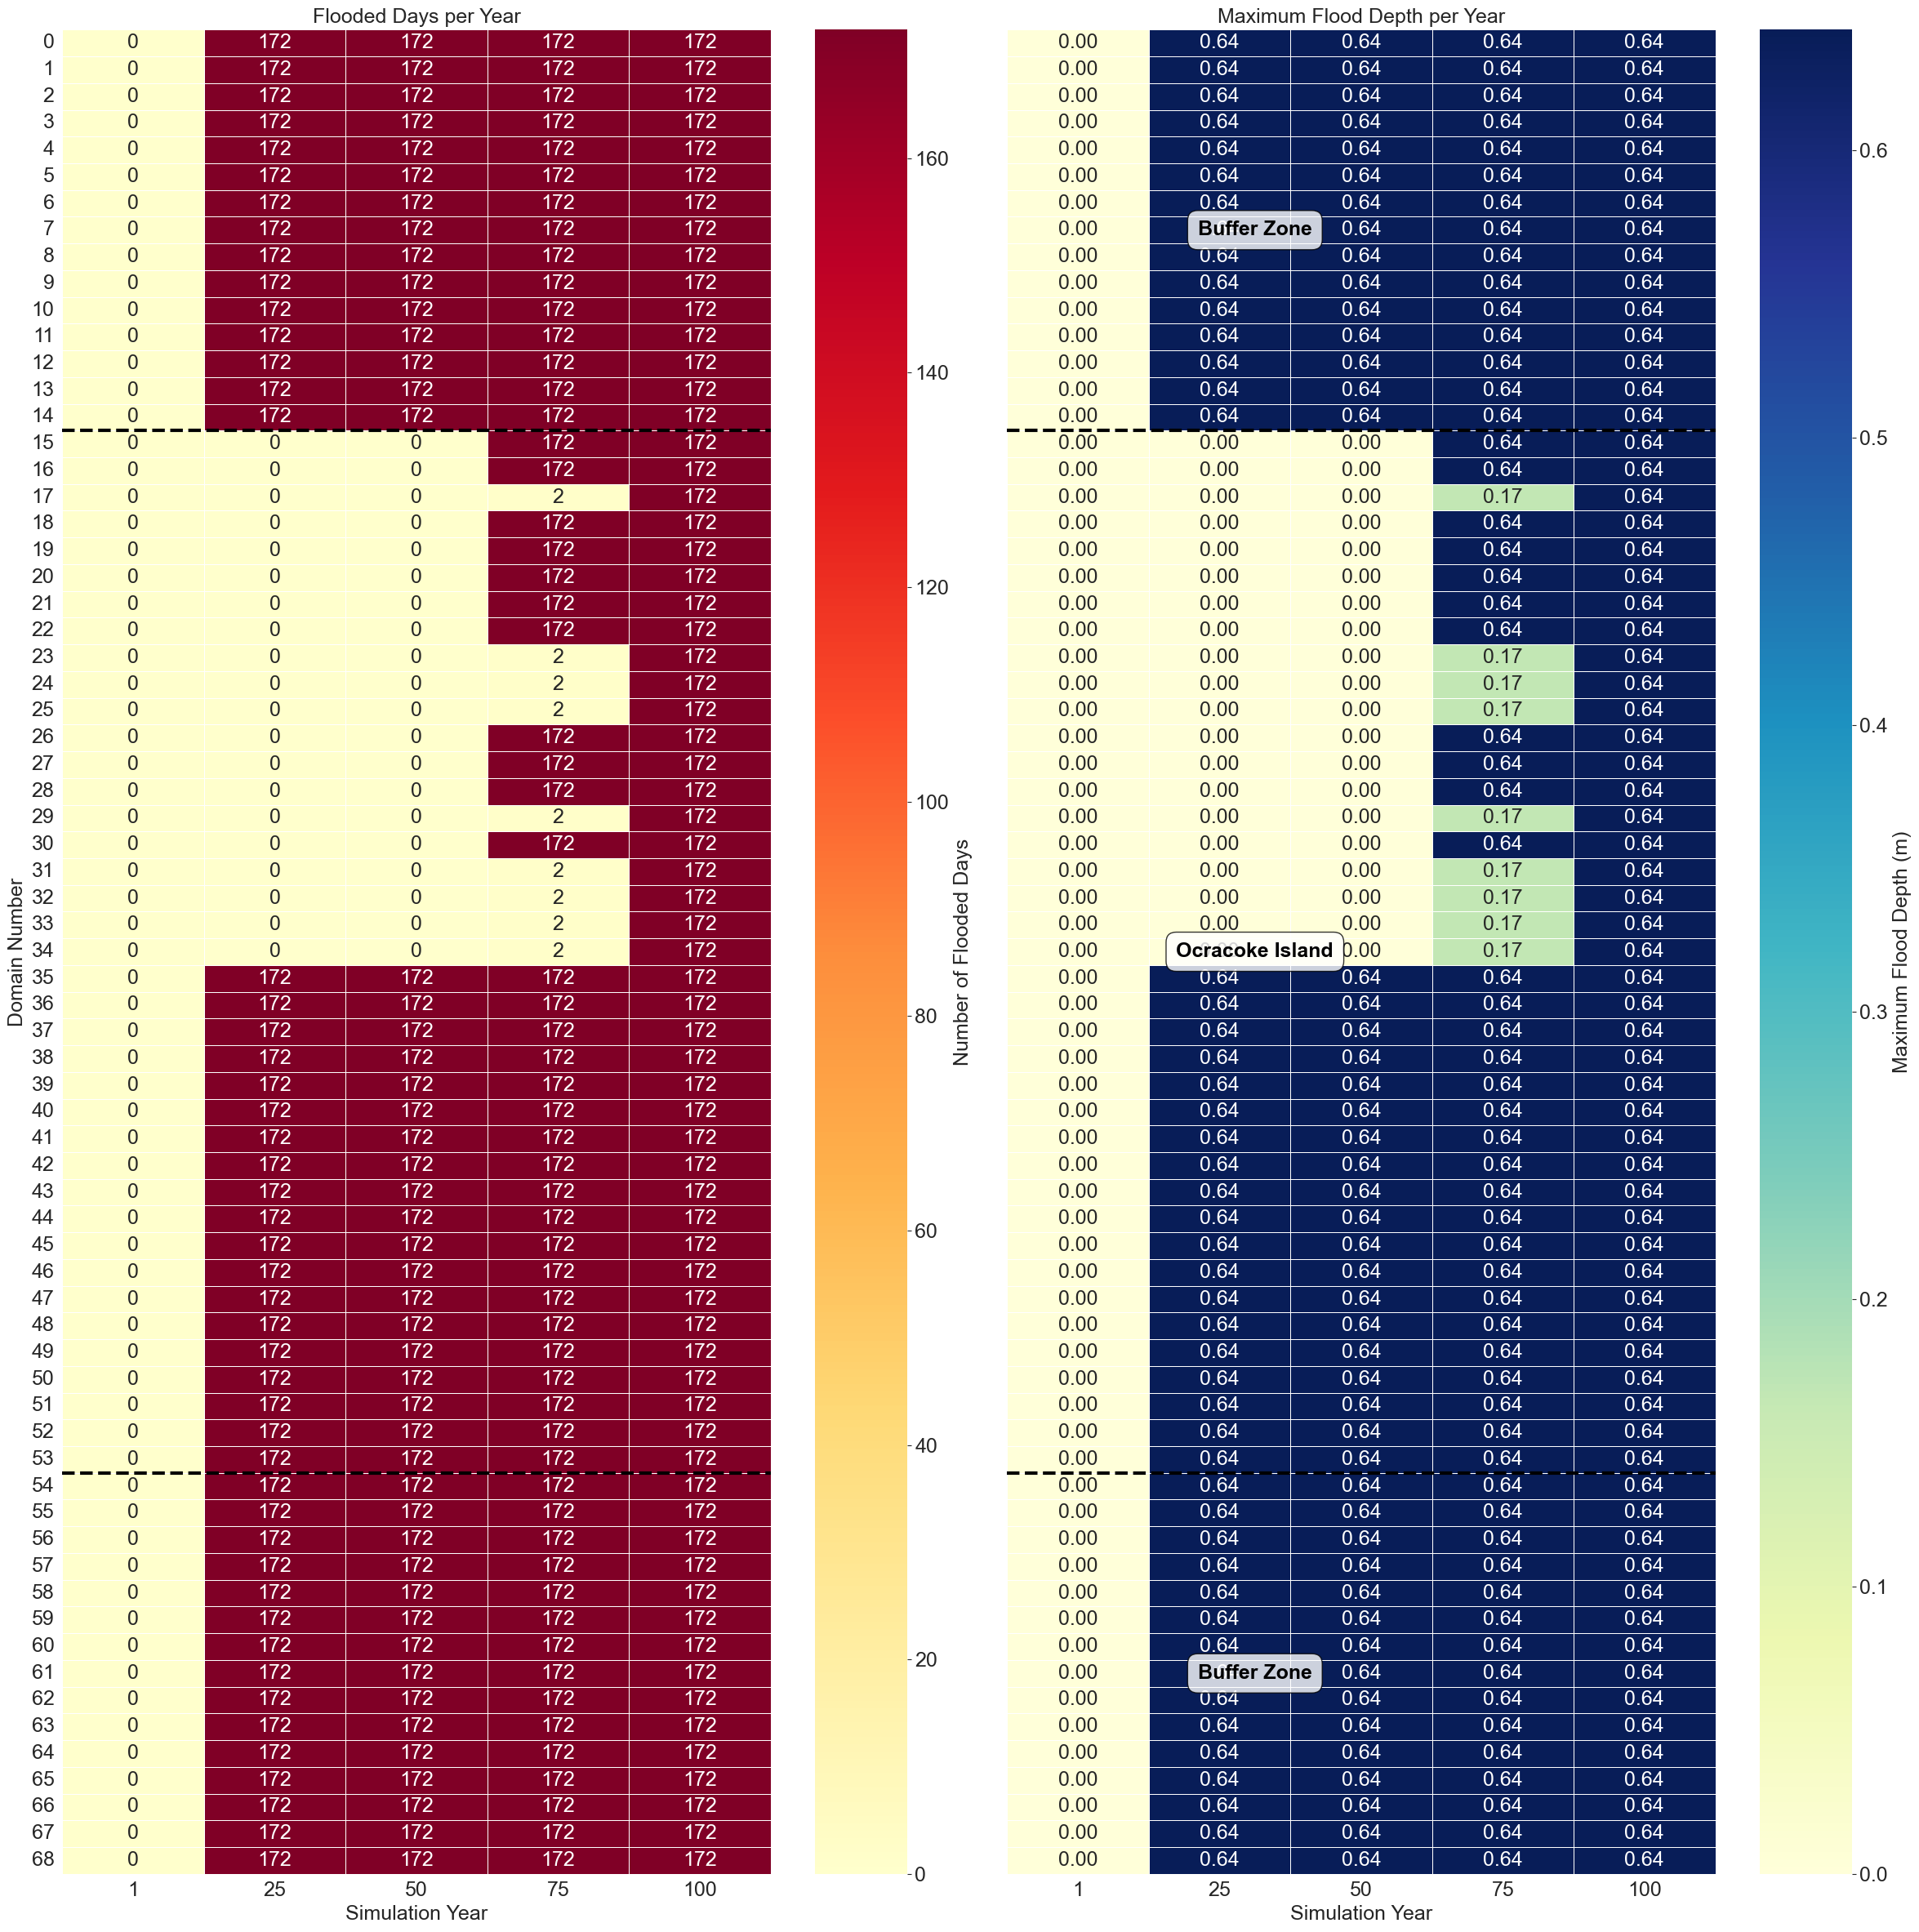

In [263]:
plt.rcParams.update({'font.size': 18})
# Create two pivot tables, one for each variable
heatmap_days = results_df.pivot_table(index='Domain', columns='Year', values='Flooded_Days')
heatmap_depth = results_df.pivot_table(index='Domain', columns='Year', values='Max_Flood_Depth_m_MHW')

# Create a figure with two subplots 
fig, axes = plt.subplots(1, 2, figsize=(24, 24), sharey=True) # sharey=True aligns the domain rows
sns.set_style("whitegrid")

text_props = dict(ha='center', va='center', fontsize=18, color='black', weight='bold')
bbox_props = dict(boxstyle='round,pad=0.5', fc='white', ec='black', lw=1, alpha=0.8)

# Plot 1: Flooded Days 
sns.heatmap(heatmap_days, ax=axes[0], annot=True, fmt=".0f", cmap='YlOrRd', 
            linewidths=.5, cbar_kws={'label': 'Number of Flooded Days'})
axes[0].set_title('Flooded Days per Year', fontsize=18)
axes[0].set_ylabel('Domain Number', fontsize=18)
axes[0].set_xlabel('Simulation Year', fontsize=18)

# Plot 2: Maximum Flood Depth 
sns.heatmap(heatmap_depth, ax=axes[1], annot=True, fmt=".2f", cmap='YlGnBu', 
            linewidths=.5, cbar_kws={'label': 'Maximum Flood Depth (m)'})
axes[1].set_title('Maximum Flood Depth per Year', fontsize=18)
axes[1].set_ylabel('') # Hide the y-label to avoid repetition
axes[1].set_xlabel('Simulation Year', fontsize=18)
plt.text(1.75, 7.5, 'Buffer Zone', **text_props, bbox=bbox_props)
plt.text(1.75, 34.5, 'Ocracoke Island', **text_props, bbox=bbox_props)
plt.text(1.75, 61.5, 'Buffer Zone', **text_props, bbox=bbox_props)

# Add horizontal lines to both plots
for ax in axes:
    ax.axhline(y=15, color='black', linestyle='--', linewidth=3)
    ax.axhline(y=54, color='black', linestyle='--', linewidth=3)
    ax.set_xticklabels(['1', '25', '50', '75', '100'])

plt.tight_layout() # Adjusts plots to prevent them from overlapping


plot_output_filename = f'/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/OCR_I_Natural_S0_Accretional_Sink.png'
plt.savefig(plot_output_filename, bbox_inches='tight')
print(f"  > Plot saved as '{plot_output_filename}'")
plt.show()